# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv',sep=',')

### Step 3. Assign it to a variable apple

In [3]:
apple = data
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


러온 data를 apple 변수에 할당하고, 데이터 구조를 확인하기 위해 상위 5개 행을 출력한다.

### Step 4.  Check out the type of the columns

In [5]:
apple.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Adj Close,float64


dtypes 속성을 사용하여 각 열의 데이터 타입을 확인 = Date 열이 object(문자열) 타입으로 되어 있는 것을 확인할 수 있다.

### Step 5. Transform the Date column as a datetime type

In [6]:
apple['Date'] = pd.to_datetime(apple['Date'])
apple['Date'].dtype

dtype('<M8[ns]')

pd.to_datetime() 함수를 통해 문자열 형태로 저장된 Date 열의 데이터 타입을 날짜/시간 객체인 datetime64 타입으로 변환한다.

### Step 6.  Set the date as the index

In [7]:
apple = apple.set_index('Date')
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


시계열 데이터 처리를 용이하게 하기 위해 Date 열을 데이터프레임의 인덱스(index)로 지정한다.

### Step 7.  Is there any duplicate dates?

In [8]:
apple.index.is_unique

True

is_unique 속성을 통해 인덱스에 중복된 날짜가 존재하는지 확인 => True가 나오면 중복된 날짜가 없음을 의미

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [9]:
apple = apple.sort_index(ascending=True)
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41


sort_index(ascending=True)를 실행하여 내림차순(최신순)으로 정렬되어 있던 날짜를 가장 오래된 날짜부터 오름차순으로 재정렬한다.

### Step 9. Get the last business day of each month

In [10]:
apple_month = apple.resample('BM').mean()
apple_month.head()

/tmp/ipykernel_3800/3505014881.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  apple_month = apple.resample('BM').mean()


,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,30.481538,30.567692,30.443077,30.443077,2.586252e+07,0.473077
1981-01-30,31.754762,31.826667,31.654762,31.654762,7.249867e+06,0.493810
1981-02-27,26.480000,26.572105,26.407895,26.407895,4.231832e+06,0.411053
1981-03-31,24.937727,25.016818,24.836364,24.836364,7.962691e+06,0.387727
1981-04-30,27.286667,27.368095,27.227143,27.227143,6.392000e+06,0.423333


resample('BM')(Business Month End)을 사용하여 각 월의 마지막 영업일을 기준으로 데이터를 리샘플링하고 평균값을 계산한다.

### Step 10.  What is the difference in days between the first day and the oldest

In [11]:
(apple.index.max() - apple.index.min()).days

12261

데이터셋의 가장 최근 날짜(max())와 가장 오래된 날짜(min())의 차이를 계산한 뒤 .days로 총 일수(day) 차이를 구한다.

### Step 11.  How many months in the data we have?

In [12]:
len(apple.resample('BM').mean())

/tmp/ipykernel_3800/1485066627.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  len(apple.resample('BM').mean())


404

월별 마지막 영업일 기준(resample('BM'))으로 데이터를 그룹화한 후 전체 행의 개수를 세어 데이터에 포함된 총 월 수를 계산한다.

### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

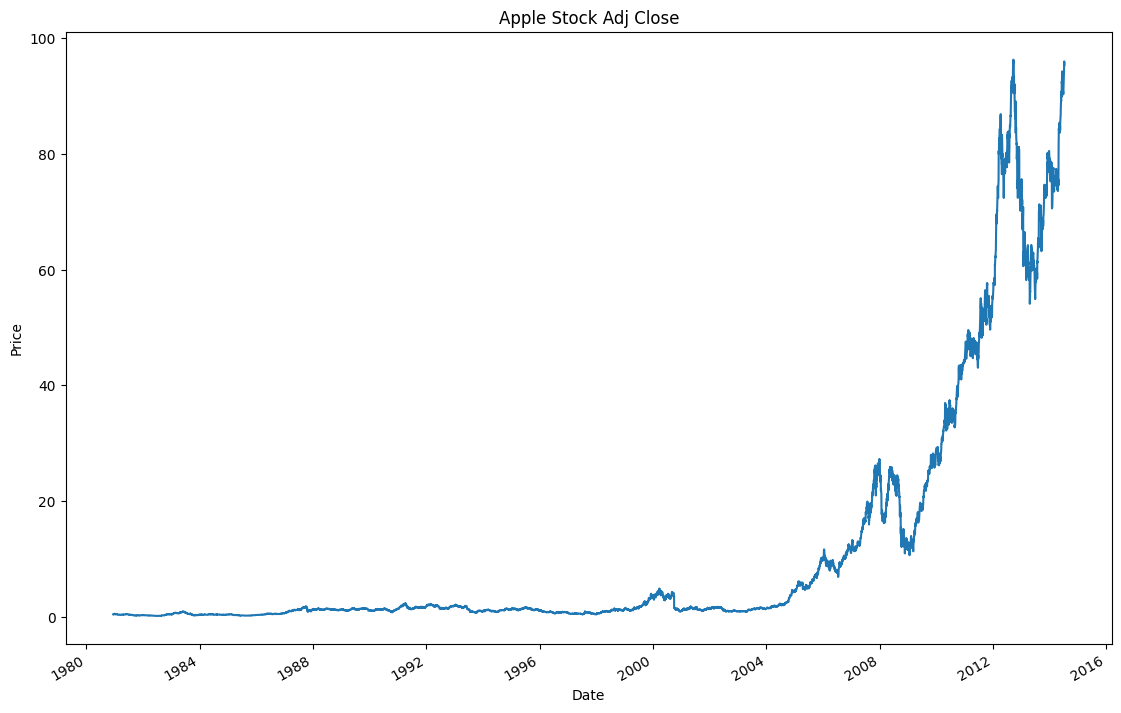

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13.5, 9))
apple['Adj Close'].plot()
plt.title('Apple Stock Adj Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

matplotlib.pyplot을 불러온 뒤 figsize=(13.5, 9)로 그래프 크기를 설정하고 애플의 조정 종가(Adj Close) 추이를 선 그래프로 출력한다.